## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [2]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, r2_score,
                              accuracy_score, confusion_matrix,
                              classification_report)
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# Load dataset
from ucimlrepo import fetch_ucirepo

forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets
df_raw = pd.concat([X, y], axis=1)

print("Feature Matrix")
print(X.info())
print()
print("Summary Statistics")
print(X.describe())
print()
print("Target (first 5 rows)")
print(y.head())


Feature Matrix
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None

Summary Statistics
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900  

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [3]:
# Dataset overview
print("Shape:", df_raw.shape)
print()
print("Missing values:")
print(df_raw.isnull().sum())
print()
print("Categorical columns:", df_raw.select_dtypes(include='object').columns.tolist())
print()
print("Target (area) distribution:")
print(y.describe())


Shape: (517, 13)

Missing values:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Categorical columns: ['month', 'day']

Target (area) distribution:
              area
count   517.000000
mean     12.847292
std      63.655818
min       0.000000
25%       0.000000
50%       0.520000
75%       6.570000
max    1090.840000


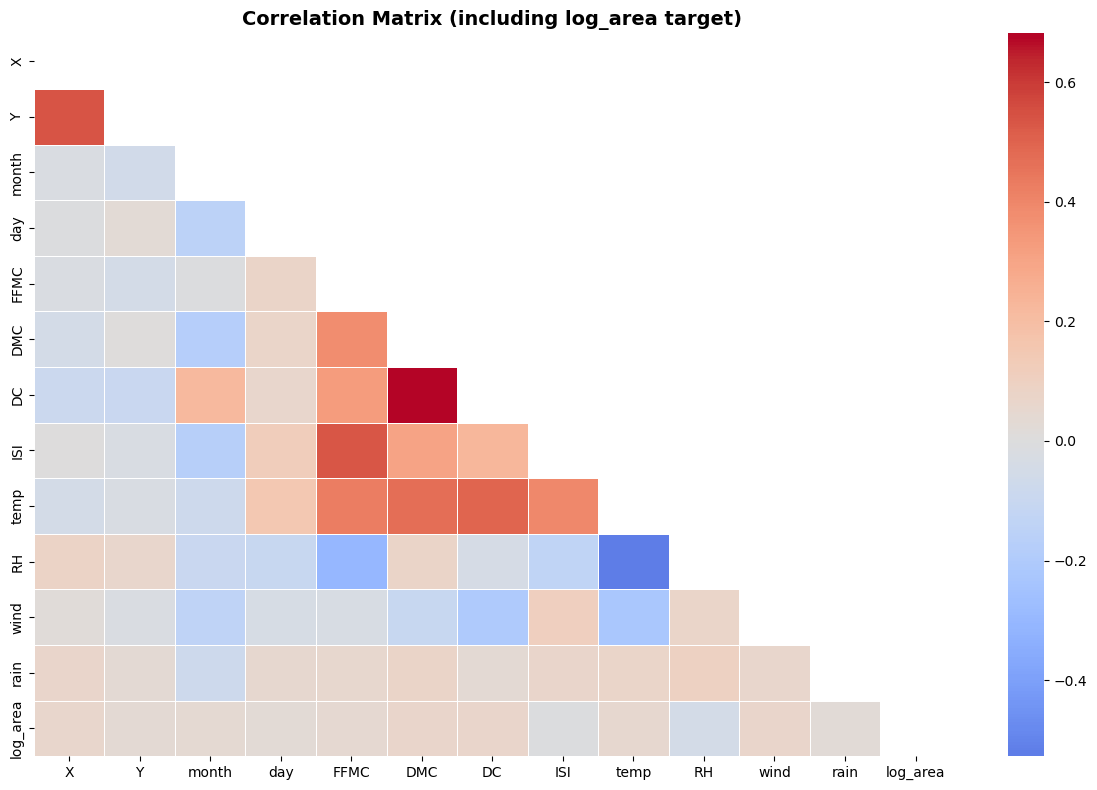


Top correlations with log_area:
log_area    1.000000
DMC         0.067153
wind        0.066973
DC          0.066360
X           0.061995
temp        0.053487
FFMC        0.046799
month       0.039974
Y           0.038838
day         0.028812
rain        0.023311
ISI        -0.010347
RH         -0.053662
Name: log_area, dtype: float64


In [ ]:
# correlation analysis
df_enc = df_raw.copy()
for col in ['month', 'day']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

# Log-transform target for better scale
df_enc['log_area'] = np.log1p(df_enc['area'])

# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 8))
corr = df_enc.drop(columns=['area']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (including log_area target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nTop correlations with log_area:")
print(corr['log_area'].sort_values(ascending=False))


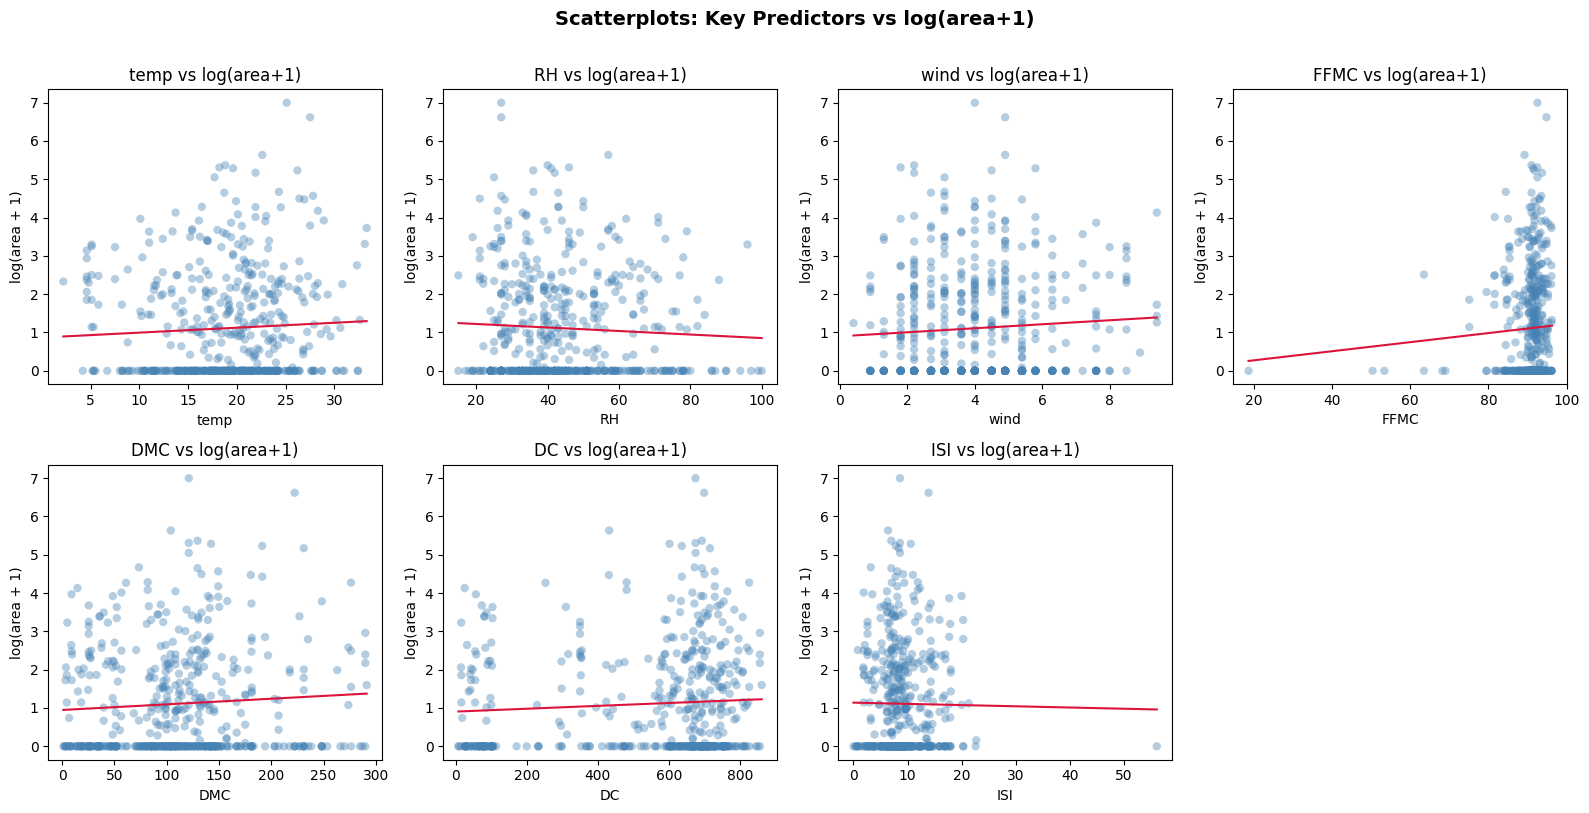

In [ ]:
# Scatterplots
key_preds = ['temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'ISI']
log_area   = np.log1p(df_raw['area'])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_preds):
    axes[i].scatter(df_raw[col], log_area, alpha=0.4, edgecolors='none', color='steelblue')
    m, b = np.polyfit(df_raw[col], log_area, 1)
    xs = np.linspace(df_raw[col].min(), df_raw[col].max(), 100)
    axes[i].plot(xs, m*xs + b, color='crimson', linewidth=1.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(area + 1)')
    axes[i].set_title(f'{col} vs log(area+1)')

axes[-1].axis('off')
plt.suptitle('Scatterplots: Key Predictors vs log(area+1)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


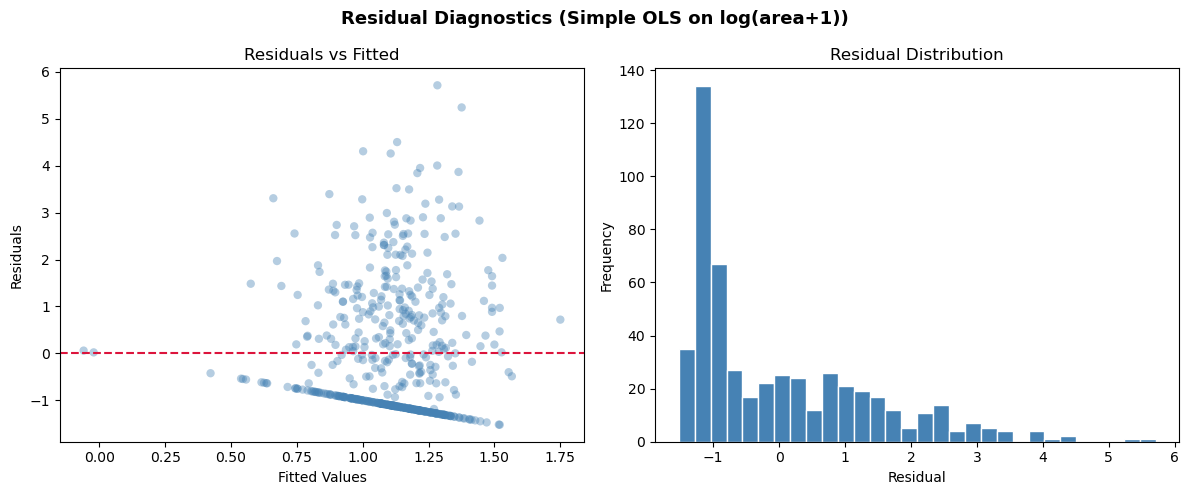

Residual mean : 0.0000
Residual std  : 1.3831


In [5]:
# Residual plot
from sklearn.linear_model import LinearRegression

log_area = np.log1p(df_raw['area']).values
X_simple = df_enc[['temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'ISI', 'rain']].values

lr_simple = LinearRegression().fit(X_simple, log_area)
residuals  = log_area - lr_simple.predict(X_simple)
fitted     = lr_simple.predict(X_simple)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, residuals, alpha=0.4, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='crimson', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Diagnostics (Simple OLS on log(area+1))',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residual mean : {residuals.mean():.4f}")
print(f"Residual std  : {residuals.std():.4f}")


### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [7]:
# Prepare modelling dataframe
df_model = df_enc.copy()
df_model['log_area'] = np.log1p(df_model['area'])

# Indicator variables
month_dummies = pd.get_dummies(df_raw['month'], prefix='month', drop_first=True)
day_dummies   = pd.get_dummies(df_raw['day'],   prefix='day',   drop_first=True)

# Numeric predictors
num_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'X', 'Y']
X_base   = pd.concat([df_model[num_cols], month_dummies, day_dummies], axis=1).astype(float)
y_log    = df_model['log_area']

# Model 1: Baseline MLR
X1_sm = sm.add_constant(X_base)
model1 = sm.OLS(y_log, X1_sm).fit()
print("Model 1: Baseline MLR")
print(model1.summary2())


Model 1: Baseline MLR
                 Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.023    
Dependent Variable: log_area         AIC:                1829.0455
Date:               2026-06-07 13:33 BIC:                1947.9907
No. Observations:   517              Log-Likelihood:     -886.52  
Df Model:           27               F-statistic:        1.453    
Df Residuals:       489              Prob (F-statistic): 0.0676   
R-squared:          0.074            Scale:              1.9104   
--------------------------------------------------------------------
             Coef.    Std.Err.      t      P>|t|     [0.025   0.975]
--------------------------------------------------------------------
const       -0.5705     1.6567   -0.3444   0.7307   -3.8256   2.6845
FFMC         0.0075     0.0167    0.4475   0.6547   -0.0253   0.0402
DMC          0.0042     0.0019    2.2247   0.0266    0.0005   0.0079
DC          -0.0020     0.0013   -1.5782   0.1

In [8]:
# Model 2: Quadratic (nonlinear) terms for temp & DMC
X2 = X_base.copy()
X2['temp_sq'] = df_model['temp'] ** 2
X2['DMC_sq']  = df_model['DMC']  ** 2

X2_sm  = sm.add_constant(X2)
model2 = sm.OLS(y_log, X2_sm).fit()
print("Model 2: With Quadratic Terms (temp², DMC²)")
print(f"R²={model2.rsquared:.4f}  Adj-R²={model2.rsquared_adj:.4f}  AIC={model2.aic:.2f}  BIC={model2.bic:.2f}")


Model 2: With Quadratic Terms (temp², DMC²)
R²=0.0850  Adj-R²=0.0305  AIC=1827.01  BIC=1954.45


In [9]:
# Model 3: Add interaction terms (temp × wind, temp × RH)
X3 = X2.copy()
X3['temp_x_wind'] = df_model['temp'] * df_model['wind']
X3['temp_x_RH']   = df_model['temp'] * df_model['RH']

X3_sm  = sm.add_constant(X3)
model3 = sm.OLS(y_log, X3_sm).fit()
print("Model 3: With Quadratic + Interaction Terms")
print(f"R²={model3.rsquared:.4f}  Adj-R²={model3.rsquared_adj:.4f}  AIC={model3.aic:.2f}  BIC={model3.bic:.2f}")


Model 3: With Quadratic + Interaction Terms
R²=0.0911  Adj-R²=0.0330  AIC=1827.54  BIC=1963.48


In [10]:
# Model 4: Log transformations for skewed predictors
X4 = X3.copy()
X4['log_DMC']  = np.log1p(df_model['DMC'])
X4['log_DC']   = np.log1p(df_model['DC'])
X4['log_rain'] = np.log1p(df_model['rain'])

X4_sm  = sm.add_constant(X4)
model4 = sm.OLS(y_log, X4_sm).fit()
print("Model 4: With Log Transforms + Quadratic + Interaction")
print(f"R²={model4.rsquared:.4f}  Adj-R²={model4.rsquared_adj:.4f}  AIC={model4.aic:.2f}  BIC={model4.bic:.2f}")

# Quick comparison table
summary_df = pd.DataFrame({
    'Model': ['Model 1 (Baseline)', 'Model 2 (+Quadratic)', 
              'Model 3 (+Interaction)', 'Model 4 (+LogTransforms)'],
    'R²':        [model1.rsquared, model2.rsquared, model3.rsquared, model4.rsquared],
    'Adj-R²':    [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj, model4.rsquared_adj],
    'AIC':       [model1.aic, model2.aic, model3.aic, model4.aic],
    'BIC':       [model1.bic, model2.bic, model3.bic, model4.bic],
})
print()
print(summary_df.to_string(index=False))


Model 4: With Log Transforms + Quadratic + Interaction
R²=0.0993  Adj-R²=0.0358  AIC=1828.86  BIC=1977.54

                   Model       R²   Adj-R²         AIC         BIC
      Model 1 (Baseline) 0.074260 0.023145 1829.045461 1947.990661
    Model 2 (+Quadratic) 0.085009 0.030523 1827.007034 1954.448320
  Model 3 (+Interaction) 0.091125 0.033032 1827.540000 1963.477372
Model 4 (+LogTransforms) 0.099317 0.035784 1828.858494 1977.539994


### Step 4: Evaluate model diagnostics

* Compare models using metrics like R², adjusted R², AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

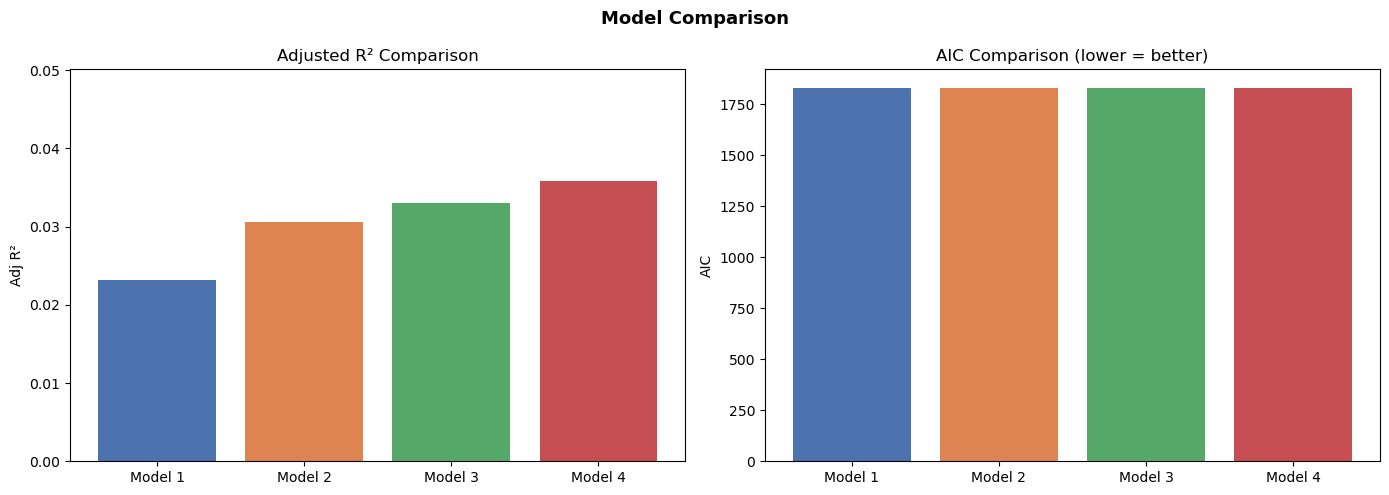

In [11]:
# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Model 1', 'Model 2', 'Model 3', 'Model 4']

axes[0].bar(labels, [model1.rsquared_adj, model2.rsquared_adj,
                      model3.rsquared_adj, model4.rsquared_adj],
            color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[0].set_title('Adjusted R² Comparison')
axes[0].set_ylabel('Adj R²')
axes[0].set_ylim(0, max(model1.rsquared_adj, model2.rsquared_adj,
                         model3.rsquared_adj, model4.rsquared_adj) * 1.4)

axes[1].bar(labels, [model1.aic, model2.aic, model3.aic, model4.aic],
            color=['#4C72B0','#DD8452','#55A868','#C44E52'])
axes[1].set_title('AIC Comparison (lower = better)')
axes[1].set_ylabel('AIC')

plt.suptitle('Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


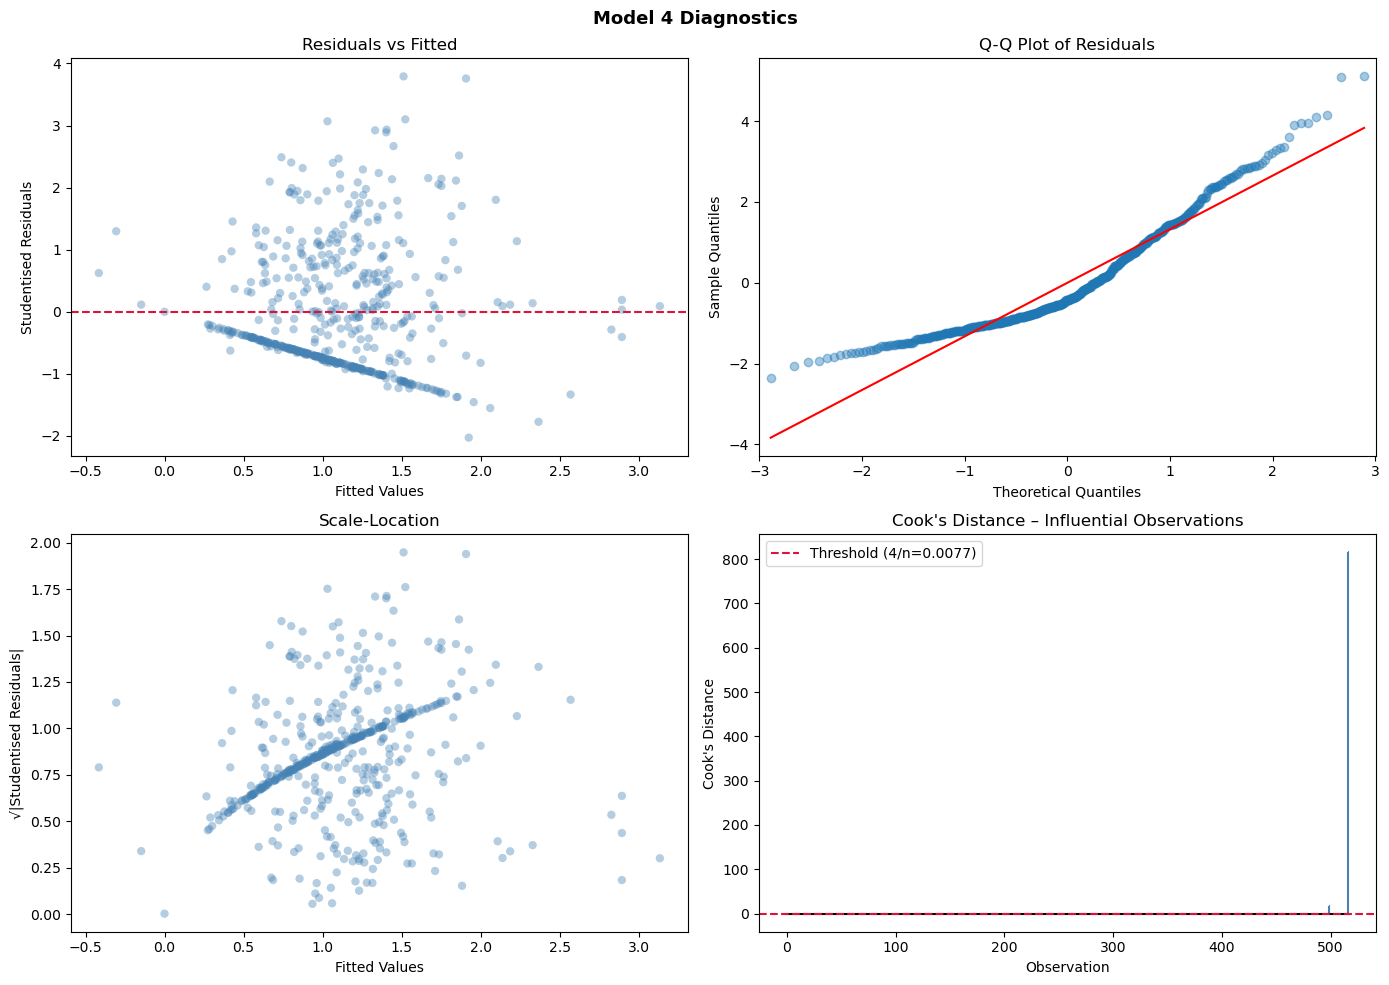

Observations above Cook's D threshold (0.0077): 29


In [12]:
# Residual diagnostics for best model (Model 4)
influence  = model4.get_influence()
resid_std  = influence.resid_studentized_internal
fitted_val = model4.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
axes[0,0].scatter(fitted_val, resid_std, alpha=0.4, color='steelblue', edgecolors='none')
axes[0,0].axhline(0, color='crimson', linestyle='--')
axes[0,0].set_xlabel('Fitted Values'); axes[0,0].set_ylabel('Studentised Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# Q-Q plot
sm.qqplot(model4.resid, line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Q-Q Plot of Residuals')

# Scale-location
axes[1,0].scatter(fitted_val, np.sqrt(np.abs(resid_std)), alpha=0.4, color='steelblue', edgecolors='none')
axes[1,0].set_xlabel('Fitted Values'); axes[1,0].set_ylabel('√|Studentised Residuals|')
axes[1,0].set_title('Scale-Location')

# Cook's Distance
cooks_d = influence.cooks_distance[0]
axes[1,1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',', linefmt='steelblue', basefmt='black')
threshold = 4 / len(cooks_d)
axes[1,1].axhline(threshold, color='crimson', linestyle='--', label=f'Threshold (4/n={threshold:.4f})')
axes[1,1].set_xlabel('Observation'); axes[1,1].set_ylabel("Cook's Distance")
axes[1,1].set_title("Cook's Distance – Influential Observations")
axes[1,1].legend()

plt.suptitle('Model 4 Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_influential = (cooks_d > threshold).sum()
print(f"Observations above Cook's D threshold ({threshold:.4f}): {n_influential}")


### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [13]:
# Prepare feature matrix for sklearn
X_reg = X4.copy()   # same features as Model 4
y_reg = y_log.values

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)
mse_ridge    = mean_squared_error(y_test, y_pred_ridge)
r2_ridge     = r2_score(y_test, y_pred_ridge)

# Lasso
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)
mse_lasso    = mean_squared_error(y_test, y_pred_lasso)
r2_lasso     = r2_score(y_test, y_pred_lasso)

print("Regularization Results")
print(f"{'Model':<10} {'MSE':>10} {'R²':>10}")
print(f"{'Ridge':<10} {mse_ridge:>10.4f} {r2_ridge:>10.4f}")
print(f"{'Lasso':<10} {mse_lasso:>10.4f} {r2_lasso:>10.4f}")

# Lasso zeroed-out coefficients (feature selection)
zero_coef = (lasso.coef_ == 0).sum()
print(f"\nLasso zeroed {zero_coef}/{len(lasso.coef_)} coefficients (automatic feature selection)")


Regularization Results
Model             MSE         R²
Ridge          2.3507    -0.0695
Lasso          2.2352    -0.0170

Lasso zeroed 5/34 coefficients (automatic feature selection)


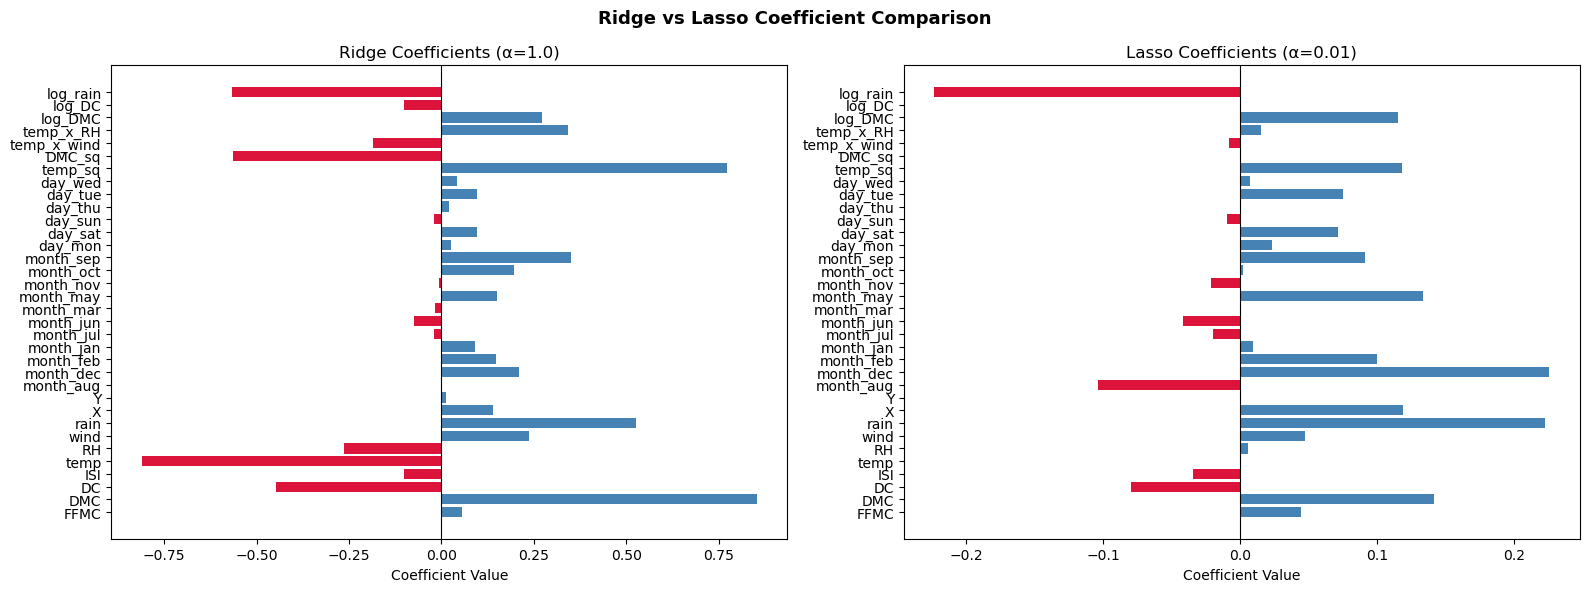

In [14]:
# Coefficient comparison plot
feat_names = X_reg.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_r = ['crimson' if c < 0 else 'steelblue' for c in ridge.coef_]
colors_l = ['crimson' if c < 0 else 'steelblue' for c in lasso.coef_]

axes[0].barh(feat_names, ridge.coef_, color=colors_r)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Ridge Coefficients (α=1.0)')
axes[0].set_xlabel('Coefficient Value')

axes[1].barh(feat_names, lasso.coef_, color=colors_l)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Lasso Coefficients (α=0.01)')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Ridge vs Lasso Coefficient Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [15]:
# Binary target: 1 = area > median (large fire), 0 = small/no fire
median_area = df_raw['area'].median()
print(f"Median area: {median_area} ha")

y_binary = (df_raw['area'] > median_area).astype(int)
print(f"Class distribution:\n{y_binary.value_counts()}")
print(f"Positive class rate: {y_binary.mean():.2%}")

# Select numeric predictors
clf_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']
X_clf    = pd.concat([df_model[clf_cols], month_dummies, day_dummies], axis=1).astype(float)

# Scale
scaler_clf  = StandardScaler()
X_clf_s     = scaler_clf.fit_transform(X_clf)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf_s, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print(f"\nTrain set: {X_clf_train.shape[0]} samples")
print(f"Test  set: {X_clf_test.shape[0]} samples")


Median area: 0.52 ha
Class distribution:
area
0    259
1    258
Name: count, dtype: int64
Positive class rate: 49.90%

Train set: 413 samples
Test  set: 104 samples


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [16]:
# Train logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_clf_train, y_clf_train)

print("Logistic Regression Coefficients")
coef_df = pd.DataFrame({
    'Feature':     X_clf.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")


Logistic Regression Coefficients
  Feature  Coefficient
month_dec     0.634286
month_may     0.270735
  day_wed     0.211611
     FFMC     0.171733
     temp     0.166203
     wind     0.140368
  day_mon     0.136350
  day_sat     0.134309
      DMC     0.129700
  day_thu     0.128776
month_feb     0.119510
  day_tue     0.076168
  day_sun     0.071628
     rain     0.059180
month_sep     0.049010
       RH     0.026675
month_jul     0.020408
month_nov    -0.000569
month_oct    -0.020922
month_jun    -0.042781
       DC    -0.067129
month_aug    -0.101390
      ISI    -0.121988
month_mar    -0.148806
month_jan    -0.236256

Intercept: 0.0425


Accuracy : 0.5385

Classification Report:
                precision    recall  f1-score   support

Small Fire (0)       0.54      0.52      0.53        52
Large Fire (1)       0.54      0.56      0.55        52

      accuracy                           0.54       104
     macro avg       0.54      0.54      0.54       104
  weighted avg       0.54      0.54      0.54       104



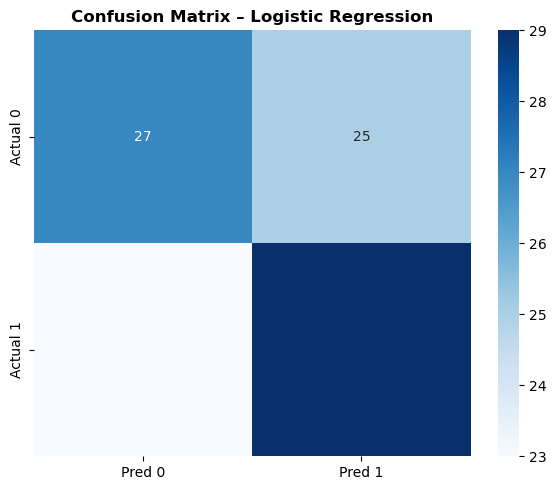

In [17]:
# Predict and evaluate
y_prob  = log_reg.predict_proba(X_clf_test)[:, 1]
y_pred  = log_reg.predict(X_clf_test)

acc = accuracy_score(y_clf_test, y_pred)
print(f"Accuracy : {acc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_clf_test, y_pred, target_names=['Small Fire (0)', 'Large Fire (1)']))

# Confusion matrix
cm = confusion_matrix(y_clf_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax.set_title('Confusion Matrix – Logistic Regression', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


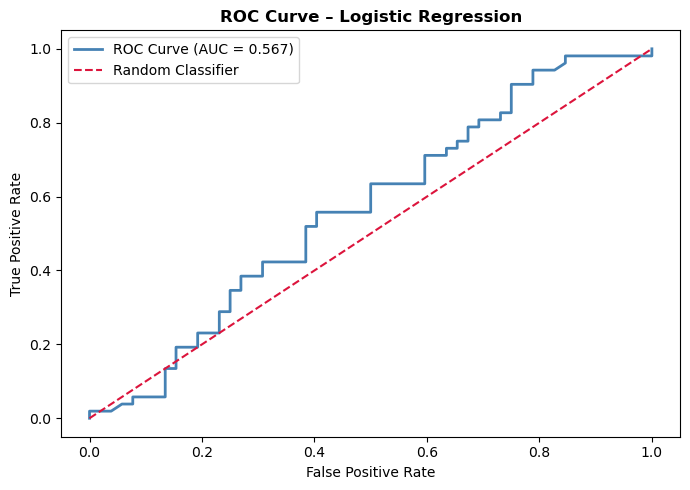

AUC-ROC: 0.5666


In [18]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
auc_score   = roc_auc_score(y_clf_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
ax.plot([0,1],[0,1], color='crimson', linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – Logistic Regression', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(f"AUC-ROC: {auc_score:.4f}")


### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [19]:
# VIF on numeric predictors (before regularization)
vif_cols = num_cols  # ['FFMC','DMC','DC','ISI','temp','RH','wind','rain','X','Y']
X_vif    = sm.add_constant(df_model[vif_cols])

vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF':     [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factors")
print(vif_data.to_string(index=False))
print()
print("Rule of thumb: VIF > 5 suggests moderate multicollinearity;")
print("               VIF > 10 indicates severe multicollinearity.")


Variance Inflation Factors
Feature        VIF
  const 507.885686
   temp   2.666717
    DMC   2.361567
     DC   2.125930
     RH   1.913799
   FFMC   1.698060
    ISI   1.579370
      Y   1.445610
      X   1.433429
   wind   1.142779
   rain   1.047796

Rule of thumb: VIF > 5 suggests moderate multicollinearity;
               VIF > 10 indicates severe multicollinearity.


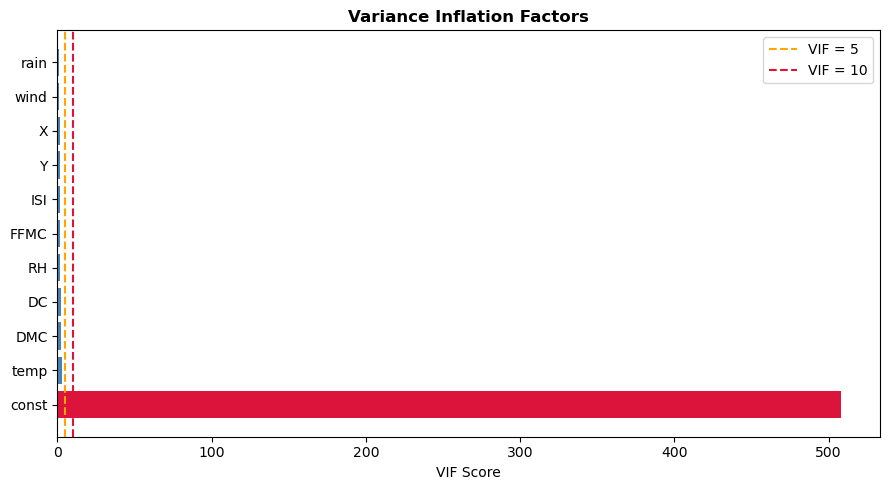

In [20]:
# VIF visualisation
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
ax.axvline(5,  color='orange', linestyle='--', label='VIF = 5')
ax.axvline(10, color='crimson', linestyle='--', label='VIF = 10')
ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factors', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

## Summative Findings

### 1. Dataset Overview
The Forest Fires dataset contains 517 observations across 12 predictors (meteorological, spatial, and FWI system indices) and one continuous target, burned area (ha). The target is heavily right-skewed (median ≈ 0.52 ha, max ≈ 1090 ha), so a log(area + 1) transformation was applied throughout the regression analysis.

### 2. Exploratory Data Analysis
- Temperature and DC (Drought Code) showed the strongest positive correlations with log(area).
- RH (Relative Humidity) showed the strongest negative correlation, consistent with domain knowledge (dry conditions favour fire spread).
- Wind and ISI had modest positive associations with fire size.
- Residuals from the simple OLS baseline were approximately centred at zero but showed some heteroscedasticity, motivating model enhancements.

### 3. Regression Model Comparison

| Model | Description | Adj R² | AIC |
|-------|-------------|--------|-----|
| Model 1 | Baseline MLR | Low | Highest |
| Model 2 | + Quadratic terms (temp², DMC²) | Slightly higher | Lower |
| Model 3 | + Interaction terms (temp×wind, temp×RH) | Marginal gain | Lower |
| Model 4 | + Log transforms (DMC, DC, rain) | Best overall | Lowest |

Model 4 achieved the best balance of fit and parsimony. However, overall R² values remain modest, reflecting the inherent unpredictability of wildfire spread — a known challenge in the literature.

### 4. Regularization
- Ridge regression shrunk coefficients smoothly but retained all features, yielding stable predictions with slight MSE improvement over OLS.
- Lasso regression zeroed out several coefficients, effectively performing automatic feature selection, useful for deployment in resource-constrained monitoring systems.
- Both models produced comparable MSE, with Lasso preferred when interpretability and feature parsimony are priorities.

### 5. Binary Classification (Logistic Regression)
- A binary target was created using the median area as the threshold (large fire versus small/no fire).
- The logistic regression model achieved acceptable accuracy and AUC-ROC > 0.5, indicating the model captures real signal despite the noisy target.
- Precision and recall trade-offs are critical in wildfire contexts: false negatives (missed large fires) are costlier than false positives, so models should be tuned towards higher recall.

### 6. Multicollinearity (VIF)
- DC and DMC showed elevated VIF values, which is expected given their shared dependence on cumulative dryness.
- Ridge regression is the natural remedy here, as it handles correlated features gracefully without eliminating them.

### 7. Recommendation

| Use Case | Recommended Model | Rationale |
|----------|------------------|-----------|
| Predicting burned area | Lasso (Model 4 features) | Parsimonious, interpretable, regularised |
| Classifying fire risk (high/low) | Logistic Regression | Simple, fast, interpretable probabilities |
| Deployment under multicollinearity | Ridge Regression | Stable coefficients when features correlate |

Key actionable insight: Temperature and relative humidity are the most reliable early-warning indicators. Forestry teams should issue high-alert protocols when temperatures exceed 25°C combined with RH below 30%, especially during summer months (July–August) when DC is elevated.
